In [11]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor,Ridge
from sklearn.metrics import r2_score,root_mean_squared_error

import numpy as np
import matplotlib.pyplot as plt

In [3]:
X , y = load_diabetes( return_X_y=True ) # Load Diabetes dataset

In [4]:
X_train ,X_test , y_train , y_test = train_test_split( X , y , test_size = 0.2 , random_state = 42)

In [5]:
X_train.shape,y_train.shape

((353, 10), (353,))

In [ ]:
# Using the Normal SGDRegressor (GD) on this so that we can later compare with our model
sgd = SGDRegressor(alpha = 0.001, eta0 = 0.01 , penalty= 'l2'  , max_iter = 500 , learning_rate = 'constant')
# penalty - the type of penalty for fitting ; In our case l2 (Ridge Regression)
# learning rate - 'constant' : Meaning we have not applied any scheduling for learning rate so it remains through the process
# eta0 : Learning rate value (eta)
# max_iter : Epochs / No of iteration u should check before stopping
# alpha : Lambda value in the Ridge Regression

In [7]:
sgd.fit(X_train,y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,500
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [8]:
sgd.coef_,sgd.intercept_

(array([  53.23572028,  -85.78926778,  336.38547856,  231.38291773,
          -0.70378833,  -34.72233614, -168.8873608 ,  137.69438771,
         264.89144765,  136.2490984 ]),
 array([151.12032839]))

In [9]:
y_pred_sgd = sgd.predict(X_test)

In [10]:
r2_score(y_test,y_pred_sgd),root_mean_squared_error(y_test,y_pred_sgd)

(0.44022592150016515, 54.458865327678)

In [12]:
# Now we will do the same but using Ridge
rdg = Ridge(alpha=0.001,max_iter=500,solver='sparse_cg')

In [13]:
rdg.fit(X_train,y_train)

,alpha,0.001
,fit_intercept,True
,copy_X,True
,max_iter,500
,tol,0.0001
,solver,'sparse_cg'
,positive,False
,random_state,None


In [14]:
rdg.coef_,rdg.intercept_

(array([  38.48350697, -241.35179372,  543.83518162,  346.78283303,
        -827.70199148,  437.17375182,  116.9497504 ,  260.75926817,
         696.12922689,   49.74344986]),
 np.float64(151.34198054847556))

In [17]:
y_pred_rdg = rdg.predict(X_test)

In [18]:
r2_score(y_test,y_pred_rdg),root_mean_squared_error(y_test,y_pred_rdg)

(0.45342802980618724, 53.812835267922026)

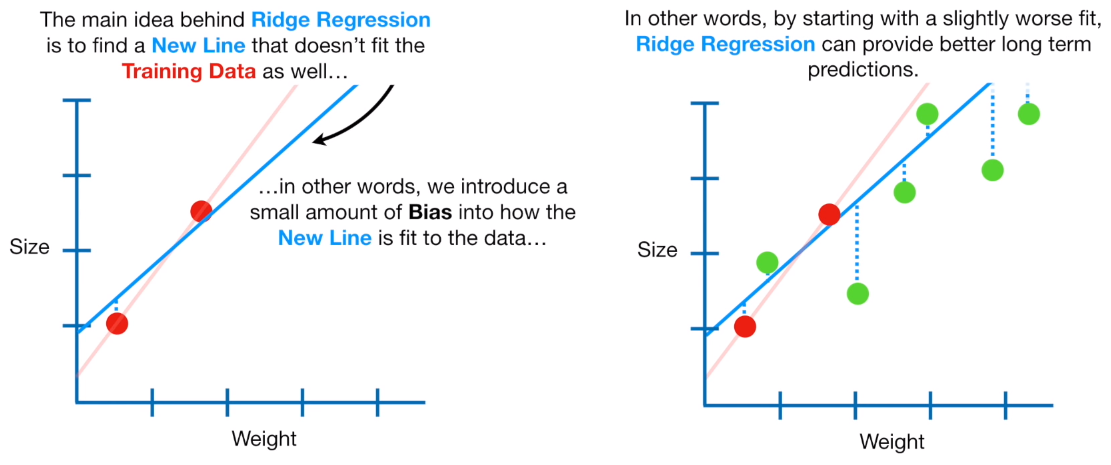

When a model is "too fit" to the training data, it is essentially memorizing the noise (the random errors) instead of learning the underlying pattern. This results in High Variance: the model changes wildly if the data changes slightly. Generalization over Memorization By adding that penalty, you are intentionally adding a little bit of Bias (simplifying the model) to get a massive reduction in Variance. Without Ridge: Training Error is 0, Test Error is Huge.With Ridge: Training Error goes up slightly, but Test Error goes down. This is the definition of a model that "generalizes" well.

In [ ]:
# Now we will make our own RGD class:
class RGD:
    def __init__(self,epochs,learning_rate = 0.01 , alpha = 0.001):
        self.coef = None
        self.intercept = None
        self.alpha = alpha
        self.epochs = epochs 
        self.l = learning_rate

    def fit(self,X_train,y_train):
        #Instantiate the coef , intercept and alpha 
        self.coef = np.ones(X_train.shape[1])
        self.intercept = 0
        # Theta is W/m
        theta = np.insert(self.coef,0,self.intercept) # We simply add self.intercept value at 0th index.
        
        # Now we will modify X_train to implement these changes
        X_train = np.insert(X_train, 0 , 1 , axis=1) # Insert a column of ones at index 0 as intercept in X_train

        # Now looping over epochs 
        for i in range(self.epochs):

            #First we will calculate theta derivative for new theta
            theta_deri = (np.dot(X_train.T,X_train).dot(theta)) - (np.dot(X_train.T,y_train)) + self.alpha*theta
            theta = theta - self.l * theta_deri # We will use the formula of GD for this 


        # Now as we saw the instantiation of theta we know that theta is made of 1 column intercepts and all the other columns are coeffecients.
        self.intercept = theta[0]
        self.coef = theta[1:]


    def predict(self,X_test):   
        return (self.intercept + (np.dot(X_test,self.coef))) 


# 🛠️ Ridge Regression: Gradient Descent Iteration

### ➡️ Step 1: Input Matrix State
We begin with data for 2 cars and 2 features (Horsepower, Weight), including a bias term (column of 1s).

* **Data ($X$):** 2 cars, 2 features + Bias.
* **Target ($y$):** Price vector.
* **Parameters:** Learning rate ($\eta$) = 0.1, Penalty ($\alpha$) = 10.

$$X = \begin{bmatrix} 1 & 2 & 1 \\ 1 & 1 & 2 \end{bmatrix}, \quad y = \begin{bmatrix} 200 \\ 100 \end{bmatrix}, \quad \theta_{old} = \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix}$$

---

### ➡️ Step 2: Correlation and Projection
The machine calculates the **Feature Interaction Matrix** ($X^T X$) and multiplies it by the current weights to find the **Projection**.

* **Feature Interaction ($X^T X$):**
$$\begin{bmatrix} 2 & 3 & 3 \\ 3 & 5 & 4 \\ 3 & 4 & 5 \end{bmatrix}$$

* **Projection ($X^T X \theta$):**
$$\begin{bmatrix} 6 \\ 9 \\ 9 \end{bmatrix}$$

---

### ➡️ Step 3: Gradient Components
Next, we calculate the **Target Direction** ($X^T y$) and the **Ridge Penalty** ($\alpha \theta$).

* **Target Direction ($X^T y$):**
$$\begin{bmatrix} 300 \\ 500 \\ 400 \end{bmatrix}$$

* **Penalty ($\alpha \theta$):**
$$\begin{bmatrix} 0 \\ 10 \\ 10 \end{bmatrix}$$

---

### ➡️ Step 4: The Final Gradient Calculation
The gradient ($grad$) is the sum of the error signal and the regularization penalty.

$$grad = (X^T X \theta) - (X^T y) + \alpha \theta$$

$$grad = \begin{bmatrix} 6 \\ 9 \\ 9 \end{bmatrix} - \begin{bmatrix} 300 \\ 500 \\ 400 \end{bmatrix} + \begin{bmatrix} 0 \\ 10 \\ 10 \end{bmatrix} = \begin{bmatrix} -294 \\ -481 \\ -381 \end{bmatrix}$$

---

### ➡️ Step 5: State Update
The machine updates the weights by taking a step in the direction opposite to the gradient.

$$\theta_{new} = \theta_{old} - (\eta \times grad)$$

$$\theta_{new} = \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix} - \left( 0.1 \times \begin{bmatrix} -294 \\ -481 \\ -381 \end{bmatrix} \right)$$

$$\theta_{new} = \begin{bmatrix} 0 \\ 1 \\ 1 \end{bmatrix} - \begin{bmatrix} -29.4 \\ -48.1 \\ -38.1 \end{bmatrix}$$

---

### ✅ Final Result
The updated weight matrix $\theta$ for the next iteration is:

$$\theta_{new} = \begin{bmatrix} 29.4 \\ 49.1 \\ 39.1 \end{bmatrix}$$

In [28]:
model = RGD(epochs=500,learning_rate=0.005,alpha=0.001)

In [29]:
model.fit(X_train,y_train)

In [30]:
y_pred_model = model.predict(X_test)

In [31]:
model.coef,model.intercept

(array([  43.37183861, -192.03766574,  496.43542567,  319.37407   ,
         -64.42788084, -113.194338  , -213.9073644 ,  144.86136322,
         367.67948022,  119.56857869]),
 np.float64(151.40454755919725))

In [32]:
r2_score(y_test,y_pred_model),root_mean_squared_error(y_test,y_pred_model)

(0.45922493769364114, 53.526706809896396)